# {docnum}`step ref` Solving ODEs Using SciPy

The particular kind of ODEs we've been solving in this chapter are initial value problems (IVPs), as we require initial conditions to be defined.

$$
\frac{dy}{dt} = f(t, y) \quad \text{width} \quad y(t_0) = y_0
$$


SciPy provides a method for solving methods: [scipy.integrate.solve_ivp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html).
The call signature for this, including only the arguments that are of immediate interest to us, is:

```python
solve_ivp(fun, t_span, y0, t_eval=None, dense_output=False, events=None, args=None)
```

where:

- `fun` - is a function for the ODE equation, given a system of $n$ coupled ODEs, this should return an array of length $n$ corresponding to the ODE for each variable. The call signature of the function should be `f(t, y)` or `f(t, y, *args)` if additional arguments are given in the `args` argument.
- `t_span` - a tuple of the start and end values of $t$.
- `y0` - the initial values of $y$.
- `t_eval` - specific values of $t$ at which the solution should be computed. If left as `None` the solver will choose these points automatically.
- `dense_output` - if `True` the method will calculate a continuous solution using interpolation. More on this later.
- `events` - a callable or list of callables. These are used to track events throughout the ODE solution by returning floating point values that change sign through a zero point when the event occurs. The call signature of the event functions should be `event(t,y)` or `event(t,y,*args)` if additional arguments are given. More on this later.

By default `solve_ivp()` will use an adaptive Runge-Kutta method of order 5 (order 4 method with local extrapolation applied).
This method can be set explicitly with the argument `method='rk45'`, or a different method can be chosen (see the documentation for a list of these).

The `solve_ivp()` function returns an object with the following attributes of interest to us:

- `t` - array of $t$ values for each integration point used.
- `y` - array of $y$ values for each $t$. The dimensions of this are `(y0.size, t.size)`.
- `sol` - The interpolated solution if `dense_output` was set to `True`.
- `t_events` - The $t$ values at which events occurred.
- `y_events` - The $y$ values at which events occured.
- `success` - boolean, `True` if the solver reached the end of `t_eval` or was terminated by an event.

<div class="worked-example">
    <p class="worked-example-title">Worked Example - Applying solve_ivp to Simple Harmonic Motion</p>

Consider the ODE:

$$
\frac{d^2y}{dt^2}(t) = - y(t)
$$

with initial conditions $y(t = 0) = 0$ and $dy/dt(t=0)=1$.

This has the exact solution:

$$
y(t) = \sin(t)
$$

to which we can compare the numerical solution.

For the numerical solution we need to reduce the second order ODE to two first order ODEs, to this end consider the variable $v = dy/dt$:

\begin{align*}
\frac{dy}{dt} &= v\\
\frac{dv}{dt} &= - y
\end{align*}


Let's apply `solve_ivp` to this and compare the results to the exact solution:

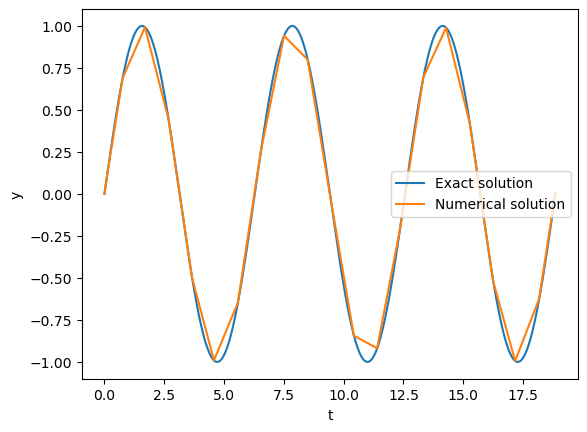

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

t_span = (0, 6 * np.pi)
y0 = np.array((0, 1))

def f(t, y):
    return np.array((y[1], -y[0]))

def y_exact(t):
    return np.sin(t)


sol = solve_ivp(f, t_span, y0)

t_plot = np.linspace(*t_span, 1000)

plt.plot(t_plot, y_exact(t_plot), label='Exact solution')
plt.plot(sol.t, sol.y[0, :], label='Numerical solution')

plt.xlabel('t')
plt.ylabel('y')

plt.legend()
sol
plt.show()

While the numerical solution seems accurate, it does not provide us a smooth curve (by design, the goal of adaptive methods is to optimize the step size).
We will explore our options to produce smoother outputs in the section below.

</div>

## Producing Smooth Curves

There are 2 main ways to produce a smooth curve for the numerical solution using `solve_ivp`:

1. Set `dense_output` to `True` and make use of the resulting interpolation.
2. Set a small step-size by using either `t_eval` or `max_step`.

It is recommended to use option 1., as this allows the adaptive solver to produce an optimal solution.
For option 2., we would be increasing the number of integration steps, thereby increasing the global error of the result.

When using `dense_output`, we use the `sol` part of the return.
This gives us a [scipy.integrate.OdeSolution](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.OdeSolution.html) object, which can be treated as a function of $t$ (as demonstrated in the worked example below).
<!-- Note that this `sol` object also has the attributes `t_min` and `t_max` which give us the minimum and maximum -->

<div class="worked-example">
    <p class="worked-example-title">Worked Example - Using dense_output in solve_ivp</p>

Using the same example of simple-harmonic motion used above, lets produce a smooth curve using `dense_output`.

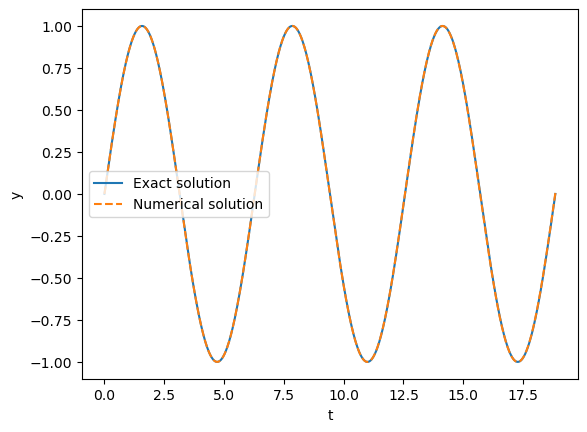

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

t_span = (0, 6 * np.pi)
y0 = np.array((0, 1))

def f(t, y):
    return np.array((y[1], -y[0]))

def y_exact(t):
    return np.sin(t)


sol = solve_ivp(f, t_span, y0, dense_output=True)

t_plot = np.linspace(*t_span, 1000)

plt.plot(t_plot, y_exact(t_plot), label='Exact solution')
plt.plot(t_plot, sol.sol(t_plot)[0, :], '--', label='Numerical solution')

plt.xlabel('t')
plt.ylabel('y')

plt.legend()
plt.show()

</div>

## Using Events

Events can be passed into `solve_ivp` using the argument `events`.
Events are defined using callables (functions) that return a floating point value, the event occurs where the function goes to zero through a sign-change.
`solve_ivp` will find accurate values of `t` for each zero of the event functions using a root finding algorithm.
The `t` and `y` values for the events are returned as `t_events` and `y_events` respectively; these are arrays if a single event was defined or a list of arrays if multiple events were defined.
Note that for the `y_events` arrays the first axis represents the number of event occurrences and the second axis represents the y variables (unlike the regular `y` values returned by `solve_ivp`).

<div class="worked-example">
    <p class="worked-example-title">Worked Example - Using events in solve_ivp</p>

Let's use some events in our simple-harmonic-motion example.
We will find the points of equilibrium ($y(t) = 0$) and the peaks and troughs ($|y(t)| = 1$ or $dy/dt(t) = 0$).

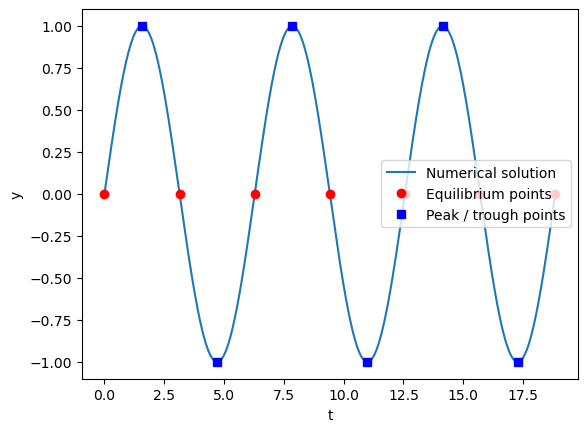

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

t_span = (0, 6 * np.pi)
y0 = np.array((0, 1))

def f(t, y):
    return np.array((y[1], -y[0]))

def event_eq(t, y):
    return y[0]

def event_peak(t, y):
    return y[1]

sol = solve_ivp(f, t_span, y0, dense_output=True, events=(event_eq, event_peak))

t_plot = np.linspace(*t_span, 1000)

plt.plot(t_plot, sol.sol(t_plot)[0, :], label='Numerical solution')
plt.plot(sol.t_events[0], sol.y_events[0][:, 0], 'ro', label='Equilibrium points')
plt.plot(sol.t_events[1], sol.y_events[1][:, 0], 'bs', label='Peak / trough points')

plt.xlabel('t')
plt.ylabel('y')

plt.legend()
plt.show()

</div>

### Using Events to End the Solution

We can use events to end the solution before the final value of `t_span`.
This is achieved by setting a value for the `terminal` attribute of the event function to either:

- `True` - which will cause the ODE solution to end after the first occurrence of the event
- an integer `k`, which will cause the ODE solution to end after `k` occurrences of the event

<div class="worked-example">
    <p class="worked-example-title">Worked Example - Using events to end the solution</p>

Let's use an event to end our simple harmonic motion after 2 periods by checking for 3 equilibrium points.
Note that, as the solution will likely end before the last value of `t_span`, we have to be careful about choosing our range of `t` values when plotting (here we will use the `t_min` and `t_max` attributes of `sol`).

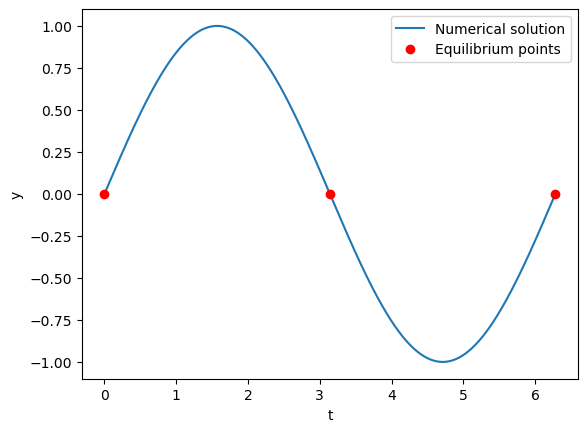

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

t_span = (0, 6 * np.pi)
y0 = np.array((0, 1))

def f(t, y):
    return np.array((y[1], -y[0]))

def event_eq(t, y):
    return y[0]

#End after 3 occurrences of the event
event_eq.terminal = 3

sol = solve_ivp(f, t_span, y0, dense_output=True, events=(event_eq))

#Using the actual min and max t values for the plot (not t_span)
t_plot = np.linspace(sol.sol.t_min, sol.sol.t_max, 1000)

plt.plot(t_plot, sol.sol(t_plot)[0, :], label='Numerical solution')
plt.plot(sol.t_events[0], sol.y_events[0][:, 0], 'ro', label='Equilibrium points')

plt.xlabel('t')
plt.ylabel('y')

plt.legend()
plt.show()

</div>

### Directional Events

We can define the direction of the zero crossing for the event.
In other words, if the function return value goes from negative to positive it has a positive direction;
if the function return value goes from positive to negative it has a negative direction.
This can be defined by setting the `direction` attribute of the event function using a floating point value (only the sign matters, a zero value - the default - will allow any direction).

<div class="worked-example">
    <p class="worked-example-title">Worked Example - Directional events</p>

Let's use directional events to isolate peaks and troughs for our simple harmonic motion example.
If $dy/dt$ goes from positive to negative (negative event direction) then it is a peak;
conversely if $dy/dt$ goes from negative to positive (positive event direction) then it is a trough.

We will define separate functions for the peak and trough events so that we can set different directions for each.

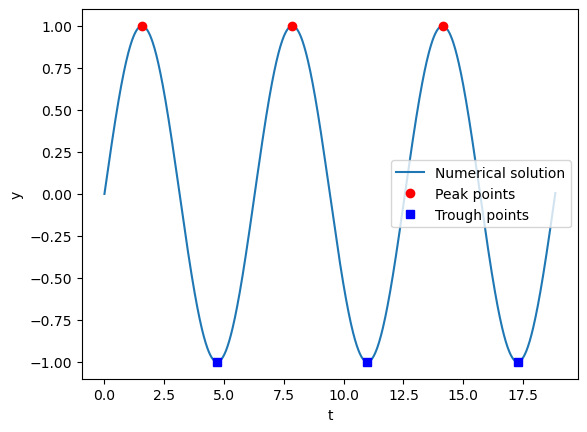

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

t_span = (0, 6 * np.pi)
y0 = np.array((0, 1))

def f(t, y):
    return np.array((y[1], -y[0]))

def event_peak(t, y):
    return y[1]

event_peak.direction = -1

def event_trough(t, y):
    return y[1]

event_trough.direction = 1

sol = solve_ivp(f, t_span, y0, dense_output=True, events=(event_peak, event_trough))

t_plot = np.linspace(*t_span, 1000)

plt.plot(t_plot, sol.sol(t_plot)[0, :], label='Numerical solution')
plt.plot(sol.t_events[0], sol.y_events[0][:, 0], 'ro', label='Peak points')
plt.plot(sol.t_events[1], sol.y_events[1][:, 0], 'bs', label='Trough points')

plt.xlabel('t')
plt.ylabel('y')

plt.legend()
plt.show()

</div>